# Using Sentinel-1 and -2 data to build a land use classification model/ Ứng dụng ảnh viễn thám Sentinel 1 và Sentinel-2  trong phân loại hiện trạng sử dụng đất (thí điểm tại xã Thuận Hòa, huyện Châu Thành, tỉnh Sóc Trăng)

## Overview/Tổng quan
This notebook will take you through a workflow for processing Sentinel-1 and -2 data./ Phần này hướng dẫn quy trình xử lý ảnh Sentinel 1 và 2

## Required datafiles/Các dữ liệu yêu cầu
This notebook requires three files:/ Trong phần này, các dữ liệu được yêu cầu bao gồm:
- A shapefile that contains land use information/Dữ liệu điểm khảo sát thực địa: `ST_training data_updated_1130points.shp`
- A raster sentinel-1 vv file (single VV polarisation)/Dữ liệu ảnh Sentinel 1 phân cực VV định dạng raster: `vv-0922_0923-full_ST.tif`
- A raster sentinel-1 vh file (single VH polarisation) )/Dữ liệu ảnh Sentinel 1 phân cực VH định dạng raster: `vh-0922_0923-full_ST.tif`
[Sentinel-1](https://sentinels.copernicus.eu/web/sentinel/user-guides/sentinel-1-sar/product-overview/polarimetry) can collect several different images from the same series of pulses by using its antenna to receive specific polarisations simultaneously. Sentinel-1 is a phase-preserving dual polarisation SAR system. It can transmit a signal in either horizontal (H) or vertical (V) polarisation, and then receive in both H and V polarisations./ Sentinel 1 là vệ tinh RADAR khẩu độ tổng hợp có thể thu thập các ảnh khác nhau từ một chuỗi ảnh bằng việc sử dụng ăng ten thu nhận đồng thời các phân cực (VH, VV). Sentinel 1 là ảnh SAR với phân cực kép, có thể truyền tín hiệu theo phân cực ngang (H), phân cực dọc (V), sau đó nhận tín hiệu ở cả phân cực H và V.

## Setting up your notebook/Cài đặt notebook của bạn

We will now setup your notebook so that you have all of the required python modules to query, analyse and plot the data./Chúng tôi sẽ thiết lập Notebook để người dùng có tất cả các mô-đun cần thiết cho truy vấn, phân tích và vẽ biểu đồ dữ liệu

### Import modules/Nhập các mô-đun

In [ ]:
%%time
# Basic plots
%matplotlib inline
import matplotlib.pyplot as plt
# plt.rcParams['figure.figsize'] = [12, 8]

# Common imports and settings
import os, sys
os.environ['USE_PYGEOS'] = '0'
from IPython.display import Markdown
import pandas as pd
pd.set_option("display.max_rows", None)
import xarray as xr

# Datacube
import datacube
from datacube.utils.rio import configure_s3_access
from datacube.utils import masking
from datacube.utils.cog import write_cog
# https://github.com/GeoscienceAustralia/dea-notebooks/tree/develop/Tools
from dea_tools.plotting import display_map, rgb
from dea_tools.datahandling import mostcommon_crs

# EASI defaults
easinotebooksrepo = '/home/jovyan/easi-notebooks'
if easinotebooksrepo not in sys.path: sys.path.append(easinotebooksrepo)
from easi_tools import EasiDefaults, xarray_object_size, notebook_utils, unset_cachingproxy
from easi_tools.load_s2l2a import load_s2l2a_with_offset

# Data tools
import numpy as np
from datetime import datetime

# Datacube
from datacube.utils import masking  # https://github.com/opendatacube/datacube-core/blob/develop/datacube/utils/masking.py
from odc.algo import enum_to_bool   # https://github.com/opendatacube/odc-algo/blob/main/odc/algo/_masking.py
from odc.algo import xr_reproject   # https://github.com/opendatacube/odc-algo/blob/main/odc/algo/_warp.py
from datacube.utils.geometry import GeoBox, box  # https://github.com/opendatacube/datacube-core/blob/develop/datacube/utils/geometry/_base.py

# Holoviews, Datashader and Bokeh
import hvplot.pandas
import hvplot.xarray
import holoviews as hv
import panel as pn
import colorcet as cc
import cartopy.crs as ccrs
from datashader import reductions
from holoviews import opts
from utils import load_data_geo
import rasterio
import os
import rioxarray
# import geoviews as gv
# from holoviews.operation.datashader import rasterize
hv.extension('bokeh', logo=False)

from deafrica_tools.bandindices import calculate_indices
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, learning_curve
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, precision_recall_fscore_support
from sklearn.model_selection import GridSearchCV, learning_curve
import seaborn as sns
import joblib

CPU times: user 18.8 s, sys: 4.27 s, total: 23 s
Wall time: 10.5 s


### Setting up dask/Thiết lập dask
We will now set up a dask cluster. The below code sets up a 'dask gateway' which allows processing of up to 10 worker nodes (cores) for fast parallel processing./Chúng ta sẽ thiết lập cụm dask. Đoạn code dưới đây cho phép thiết lập một “cổng dask” với việc xử lý tối đa 10 lõi chạy song song.
The below code usually takes about 3 minutes to run while dask starts up a new cluster. Once the cluser has initiliased, you can click Launch dashboard in JupyterLab to monitor the cluster acitivity./Code này mất 3 phút để chạy khi dask khởi tạo một cụm mới. Khởi chạy bảng điều khiển trong JupyterLan để theo dõi hoạt động của cụm vừa được tạo.

In [2]:
%%time
# Dask gateway
cluster, client = notebook_utils.initialize_dask(use_gateway=True, workers=(1,10))
client

Starting new cluster
CPU times: user 76.9 ms, sys: 19.7 ms, total: 96.6 ms
Wall time: 3min 39s


Connection method: Cluster object,Cluster type: dask_gateway.GatewayCluster
Dashboard: https://hub.asia.easi-eo.solutions/services/dask-gateway/clusters/easihub.59f43935e7fd4347b8189c8a29f94c33/status,


### Loading the datacube/Tải khối dữ liệu
Next we load the datacube object. This datacube is what we will use to read the satellite data into memory. We must also configure s3 access to the Sentinel-2 data which is available in the cloud./Datacube chính là khối dữ liệu chứa các ảnh viễn thám. Trong đó, chúng ta cần cấu hình quyền truy cập vào dữ liệu Sentinel 2 có sẵn trên đám mây.

In [3]:
# Initialise a datacube object
dc = datacube.Datacube()

# Configure s3 access
configure_s3_access(aws_unsigned=False, requester_pays=True, client=client)

### Defining a search query/Truy vấn dữ liệu
We now need to query the sentinel-2 cloud database on EASI. To extract data we define a query dictionary that contains search criteria such as spatial and temporal limits./ Bây giờ chúng ta cần truy vấn cơ sở dữ liệu đám mây Sentinel-2 trên EASI. Để trích xuất dữ liệu, xác định các tiêu chí, điều kiện truy vấn như giới hạn không gian (khu vực nghiên cứu), thời gian (giai đoạn nghiên cứu)

In [4]:
# Specify the start and end times 
min_date = '2022-09-01' # Thời gian bắt đầu lấy data cho quá trình train
max_date = '2023-10-01' # Thời gian kết thúc lấy data cho quá trình train
# Just do 1 month for testing
# max_date = '2022-10-01' # Thời gian kết thúc lấy data cho quá trình train

# Specify a spatail region to search using latitude/longitude cooridinates
min_longitude, max_longitude = (105.5, 106.4)
min_latitude, max_latitude = (9.2, 10.0)

# Specify the product. In this case we want to use Sentinel-2 Level-2A data
product = 's2_l2a'

# Construct the search query dictionary
query = {
    'product': product,                     # Product name
    'x': (min_longitude, max_longitude),    # "x" axis bounds
    'y': (min_latitude, max_latitude),      # "y" axis bounds
    'time': (min_date, max_date),           # Any parsable date strings
}

### Most common CRS/Hệ quy chiếu, phép chiếu phổ biến
We can select the most appropriate CRS projection using the notebook_utils helper function. This function takes into account the data product and spatial location and determines the most common CRS for that region. It generally takes 1-2 seconds to find the most common CRS./ Chúng ta có thể chọn phép chiếu CRS phù hợp nhất ứng dụng hàm trợ giúp notebook_utils. Hàm này xem xét cả về dữ liệu và vị trí không gian, xác định CRS phổ biến nhất cho khu vực quan sát. Thông thường sẽ mất 1-2 giây để tìm CRS phổ biến nhất.

In [5]:
# Most common CRS
native_crs = notebook_utils.mostcommon_crs(dc, query)
print(f'Most common native CRS: {native_crs}')

Most common native CRS: EPSG:32648


### Target xarray parameters/Các thông số xarray mục tiêu
Next we can define which target parameters we would like to load into our xarray object. In general we need to:/ Tiếp theo, chúng ta xác định tham số nào cần tải về cho đối tượng xrray. Cụ thể:
- Select a set of measurements to load/Chọn một tập hợp các kênh ảnh cần tải 
- Define an appropriate output CRS and resolution/Xác định hệ quy chiếu và độ phân giải ảnh
- Decide on how we group the data (usually we groupby input scenes on the same day to a single time layer)./Xác định các nhóm dữ liệu (thông thường các dữ liệu cùng ngày sẽ được nhóm vào cùng 1 lớp dữ liệu thời gian)
- Select a reasonable Dask chunk size (this should be adjusted depending on the spatial and resolution parameters you choose/Chọn kích thước Chun dask phù hợp (nó được điều chỉnh phụ thuộc vào thông số thời gian và không gian)

In [6]:
# Specify the spectral band measurements we want to use for a classification algorithm
measurements = ['blue', 'green', 'red', 'nir', 'scl']

load_params = {
    'measurements': measurements,                   # Selected measurement or alias names
    'output_crs': native_crs,                       # Target EPSG code
    'resolution': (-10, 10),                        # Target resolution
    'group_by': 'solar_day',                        # Scene grouping
    'dask_chunks': {'x': 2048, 'y': 2048},          # Dask chunks
}

### Loading the data/Tải dữ liệu
We are now read to load the data into our datacube object. For sentinel-2 data we can use the **load_s2l2a_with_offset** helper function so that the sentinel-2 scale and offset coefficients are applied correctly. More information on this issue is discussed here./ Chúng ta đang đọc để tải dữ liệu vào datacube của bản thân. Đối với dữ liệu Sentinel-2, chúng ta có thể sử dụng hàm trợ giúp **Load_s2l2a_with_offset** để thang đo Sentinel-2 và các hệ số bù được áp dụng chính xác. Thông tin thêm về vấn đề này được thảo luận ở đây.

In [7]:
%%time
# The replacement "dc.load()" function for this product
data = load_s2l2a_with_offset(
    dc,
    query | load_params   # Combine the two dicts that contain our search and load parameters
)

# This line prints the total size of the dataset hat was loaded
notebook_utils.heading(notebook_utils.xarray_object_size(data))

display(data)

No datasets require offset correction
The valid_data_mask and scale (no offset) have been applied to the reflectance bands


<xarray.Dataset> Size: 226GB
Dimensions:      (time: 151, y: 8874, x: 9902)
Coordinates:
  * time         (time) datetime64[ns] 1kB 2022-09-02T03:35:23.960000 ... 202...
  * y            (y) float64 71kB 1.106e+06 1.106e+06 ... 1.017e+06 1.017e+06
  * x            (x) float64 79kB 5.548e+05 5.548e+05 ... 6.538e+05 6.538e+05
    spatial_ref  int32 4B 32648
Data variables:
    blue         (time, y, x) float32 53GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    green        (time, y, x) float32 53GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    red          (time, y, x) float32 53GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    nir          (time, y, x) float32 53GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
    scl          (time, y, x) uint8 13GB dask.array<chunksize=(1, 2048, 2048), meta=np.ndarray>
Attributes:
    crs:           EPSG:32648
    grid_mapping:  spatial_ref

CPU times: user 1.2 s, sys: 32.4 ms, total: 1.23 s
Wall time: 1.32 s


### Masking



In [8]:
# # Get the scale factor and offset from the measurement metadata
# measurement_info = dc.list_measurements().loc[query1['product']].loc[query1['measurements']]  # Pandas dataframe
# display(measurement_info)

# The "SCL" band contains quality flags and information. The details can also be found in the metadata.
flag_name = 'scl'
flag_desc = masking.describe_variable_flags(data[flag_name])  # Pandas dataframe
display(flag_desc)
display(flag_desc.loc['qa'].values[1])

,bits,values,description
qa,"[0, 1, 2, 3, 4, 5, 6, 7]","{'0': 'no data', '1': 'saturated or defective'...",Sen2Cor Scene Classification


{'0': 'no data',
 '1': 'saturated or defective',
 '2': 'dark area pixels',
 '3': 'cloud shadows',
 '4': 'vegetation',
 '5': 'bare soils',
 '6': 'water',
 '7': 'unclassified',
 '8': 'cloud medium probability',
 '9': 'cloud high probability',
 '10': 'thin cirrus',
 '11': 'snow or ice'}

In [9]:
# Create a "data quality" Mask layer
flags_def = flag_desc.loc['qa'].values[1]
good_pixel_flags = [flags_def[str(i)] for i in [2, 4, 5, 6]]  # To pass strings to enum_to_bool()

# enum_to_bool calculates the pixel-wise "or" of each set of pixels given by good_pixel_flags
# 1 = good data
# 0 = "bad" data

good_pixel_mask = enum_to_bool(data[flag_name], good_pixel_flags)  # -> DataArray
# display(good_pixel_mask)  # Type: bool

In [10]:
data_layer_names = [x for x in data.data_vars if x != 'scl']

In [11]:
data_layer_names

['blue', 'green', 'red', 'nir']

In [12]:
from dask.distributed import progress

# Apply good pixel mask to blue, green, red and nir.
result = data[data_layer_names].where(good_pixel_mask).persist()

### Note on Dask Progress Monitoring / Lưu ý về theo dõi tiến trình Dask

**Important:** If you encounter `CommClosedError` or connection issues with Dask, the computations are still running in the background. You can:
1. Wait for the computation to complete
2. Check the Dask dashboard for progress
3. Use `compute()` directly which will wait for results

**Quan trọng:** Nếu gặp lỗi `CommClosedError` hoặc vấn đề kết nối với Dask, các tính toán vẫn đang chạy ở chế độ nền. Bạn có thể:
1. Đợi tính toán hoàn thành
2. Kiểm tra bảng điều khiển Dask để xem tiến trình
3. Sử dụng `compute()` trực tiếp sẽ đợi kết quả

In [ ]:
# Optional: Check Dask cluster status / Kiểm tra trạng thái cluster Dask (tùy chọn)
try:
    print(f"Cluster status: {client.status}")
    print(f"Number of workers: {len(client.scheduler_info()['workers'])}")
    print("Dask cluster is running properly / Cluster Dask đang hoạt động bình thường")
except Exception as e:
    print(f"Warning: Cannot connect to Dask cluster - {e}")
    print("Cảnh báo: Không thể kết nối đến cluster Dask")

In [ ]:
# This computation can take 5 minutes
# progress(result)  # Commented out to avoid connection issues

try:    print("Using persist() - data is being computed in background")

    from distributed import waitexcept:

    wait(result)  # Wait for computation without progress bar    print("Computation completed successfully!")

VBox()

2026-03-08 03:36:25,093 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7ff23d568f50>>, <Task finished name='Task-757' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=CommClosedError('in <TLS (closed)  local=tls://10.0.67.50:55866 remote=gateway://traefik-dask-gateway.easihub:80/easihub.59f43935e7fd4347b8189c8a29f94c33>: Stream is closed')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/env/lib/python3.12/si

In [14]:
ds1 = calculate_indices(result, index='NDVI', satellite_mission='s2')
ndvi = ds1["NDVI"]
average_ndvi = ndvi.resample(time='1M').mean().persist()  ## tính mean cho từng tháng -> time = 12

/env/lib/python3.12/site-packages/xarray/groupers.py:392: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  self.index_grouper = pd.Grouper(


In [ ]:
# This takes 48.8s
# progress(average_ndvi)  # Commented out to avoid connection issues

try:    print("Using persist() - NDVI data is being computed in background")

    from distributed import waitexcept:

    wait(average_ndvi)  # Wait for computation without progress bar    print("NDVI computation completed successfully!")

VBox()

2026-03-08 03:36:25,099 - tornado.application - ERROR - Exception in callback functools.partial(<bound method IOLoop._discard_future_result of <tornado.platform.asyncio.AsyncIOMainLoop object at 0x7ff23d568f50>>, <Task finished name='Task-758' coro=<MultiProgressBar.listen() done, defined at /env/lib/python3.12/site-packages/distributed/diagnostics/progressbar.py:281> exception=CommClosedError('in <TLS (closed)  local=tls://10.0.67.50:55880 remote=gateway://traefik-dask-gateway.easihub:80/easihub.59f43935e7fd4347b8189c8a29f94c33>: Stream is closed')>)
Traceback (most recent call last):
  File "/env/lib/python3.12/site-packages/distributed/comm/tcp.py", line 225, in read
    frames_nosplit_nbytes_bin = await stream.read_bytes(fmt_size)
                                ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
tornado.iostream.StreamClosedError: Stream is closed

The above exception was the direct cause of the following exception:

Traceback (most recent call last):
  File "/env/lib/python3.12/si

In [16]:
%%time
average_ndvi = average_ndvi.compute()

CPU times: user 7.63 s, sys: 4.39 s, total: 12 s
Wall time: 6min 46s


CPU times: user 561 ms, sys: 110 ms, total: 670 ms
Wall time: 664 ms


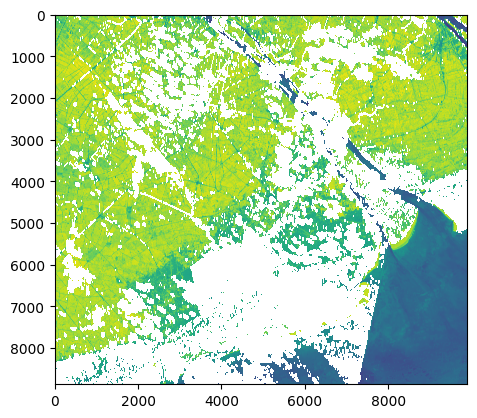

In [17]:
%%time
plt.imshow(average_ndvi.isel(time=5))

In [18]:
%%time
filled_ds = average_ndvi.bfill(dim='time')
filled_ds = filled_ds.ffill(dim='time')

CPU times: user 19.8 s, sys: 10.5 s, total: 30.3 s
Wall time: 1.08 s


CPU times: user 664 ms, sys: 131 ms, total: 794 ms
Wall time: 792 ms


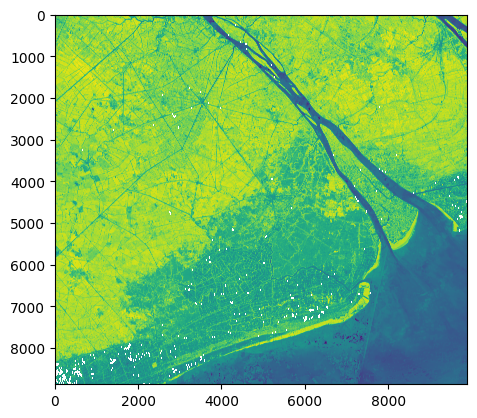

In [19]:
%%time
plt.imshow(filled_ds.isel(time=5))

In [20]:
train_path = "train/ST_training data_updated_1130points.shp"  # đường dẫn shp file train
train = load_data_geo(train_path)
train.head()

,No,X,Y,LU2022,Hientrang,HT_code,geometry
0,1.0,603860.819,1081162.862,Pomelo,CLN,5,POINT (603860.819 1081162.862)
1,2.0,601306.410,1082782.940,Pomelo,CLN,5,POINT (601306.41 1082782.94)
2,3.0,601084.510,1081351.870,Pomelo,CLN,5,POINT (601084.51 1081351.87)
3,4.0,602193.760,1079205.220,Pomelo,CLN,5,POINT (602193.76 1079205.22)
4,5.0,602459.000,1080946.000,Pomelo,CLN,5,POINT (602459 1080946)


## Downloading Sentinel-1 data/Tải ảnh Sentinel 1
The sentinel-1 data files are available via an s3 bucket. To download the files locally we will use the aws client. First, check the files are available on the s3 bucket:/ Các dữ liệu ảnh Sentinel-1 có sẵn thông qua S3 (dịch vụ lưu trữ và truy xuất của Amazon). Để tải xuống các tệp cục bộ, chúng tôi sẽ sử dụng ứng dụng khách của aws. Trước tiên, kiểm tra các tệp có sẵn trên s3:

In [21]:
%%time

# The downloads take 2-3 minutes to complete.
import os
if not os.path.exists("vh-0922_0923-full_ST.tif"):
    !aws s3 cp s3://easi-asia-dc-data/staging/ctu/sentinel-1/vh-0922_0923-full_ST.tif vh-0922_0923-full_ST.tif
if not os.path.exists("vv-0922_0923-full_ST.tif"):
    !aws s3 cp s3://easi-asia-dc-data/staging/ctu/sentinel-1/vv-0922_0923-full_ST.tif vv-0922_0923-full_ST.tif

CPU times: user 238 μs, sys: 82 μs, total: 320 μs
Wall time: 3.73 ms


### Load Sentinel-1 data/ Tải dữ liệu Senttinel từ S3

In [22]:
vvpath = 'vv-0922_0923-full_ST.tif'
vhpath = 'vh-0922_0923-full_ST.tif'

dsvv = rioxarray.open_rasterio(vvpath)
dsvh = rioxarray.open_rasterio(vhpath)

Warning 1: TIFFReadDirectory:Invalid data type for tag StripByteCounts
Warning 1: TIFFFetchNormalTag:ASCII value for tag "GeoASCIIParams" contains null byte in value; value incorrectly truncated during reading due to implementation limitations
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.
Warning 1: TIFFReadDirectory:Invalid data type for tag StripByteCounts
Warning 1: TIFFFetchNormalTag:ASCII value for tag "GeoASCIIParams" contains null byte in value; value incorrectly truncated during reading due to implementation limitations
Warning 1: TIFFReadDirectory:Sum of Photometric type-related color channels and ExtraSamples doesn't match SamplesPerPixel. Defining non-color channels as ExtraSamples.


### Label the training data/ Thống nhất nhãn dữ liệu thực địa

In [23]:
%%time

# Takes 1 minute to complete.
loaded_datasets = {}
for idx, point in train.iterrows():
    key = f"point_{idx + 1}"
    try:
        ndvi_data = filled_ds.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vh_data = dsvh.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        vv_data = dsvv.sel(x=point.geometry.x, y=point.geometry.y, method='nearest').values
        loaded_datasets[key] = {
            "data": np.concatenate((ndvi_data, vh_data, vv_data)),
            "label": point.HT_code
                               }
    except Exception as e:
        # loaded_datasets[key] = None
        print(e)

CPU times: user 2.92 s, sys: 1.7 s, total: 4.62 s
Wall time: 28.4 s


In [24]:
label_mapping = {
    "Lua tom": "0",
    "Lua": "1",
    "CHN": "2",
    "CLN": "3",
    "TS": "4",
    "Song": "5",
    "Dat xay dung": "6",
    "Rung": "7"
}
label_encoder = LabelEncoder()

# Fit and transform the labels
labels = train.Hientrang.values
numeric_labels = label_encoder.fit_transform([label_mapping[label] for label in labels])

In [25]:
X = []
x_new = []
lb_new = []
for k, v in loaded_datasets.items():
    X.append(v)
for i in range(len(X)):
    if X[i] is not None:
        x_new.append(X[i]["data"])
        lb_new.append(numeric_labels[i])

### Split training data / Chia tập dữ liệu huấn luyện

In [26]:
X_train, X_temp, y_train, y_temp= train_test_split(x_new, lb_new, test_size=0.4, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

### Model training pipeline/ huấn luyện mô hình và đánh giá trên tập validate

In [27]:
%%time

# Takes 1-2 minutes to complete

# Tạo RandomForestClassifier mặc định để sử dụng làm mô hình ban đầu trong pipeline
base_model = RandomForestClassifier(random_state=42, n_jobs=-1)

# Tạo pipeline
pipeline = Pipeline([
    # ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler()),
    ('classifier', base_model),
])
# Thiết lập các tham số bạn muốn tối ưu hóa
param_grid = {
    'classifier__n_estimators': [100, 300, 500, 700, 1000],
    'classifier__max_depth': [6, 8, 10, 15, 20],
    'classifier__criterion': ['gini', 'entropy'],
}

# Sử dụng GridSearchCV để tìm bộ tham số tốt nhất
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

# In ra bộ tham số tốt nhất
best_params = grid_search.best_params_
print("Best Parameters:", best_params)

# Dự đoán trên tập kiểm tra
y_pred = grid_search.predict(X_val)

# Đánh giá kết quả
accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {round(accuracy, 2)*100} %")

/env/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


Best Parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__n_estimators': 1000}
Accuracy: 85.0 %
CPU times: user 8.72 s, sys: 4.25 s, total: 13 s
Wall time: 18.6 s


### Accuracy on the test data/ Độ chính xác trên tập dữ liệu kiểm tra

In [28]:
## check accuracy score

y_pred_test = grid_search.predict(X_test)
test_accuracy = accuracy_score(y_test, y_pred_test)
print(f"Accuracy for test data {round(test_accuracy, 2)*100} %")

Accuracy for test data 88.0 %


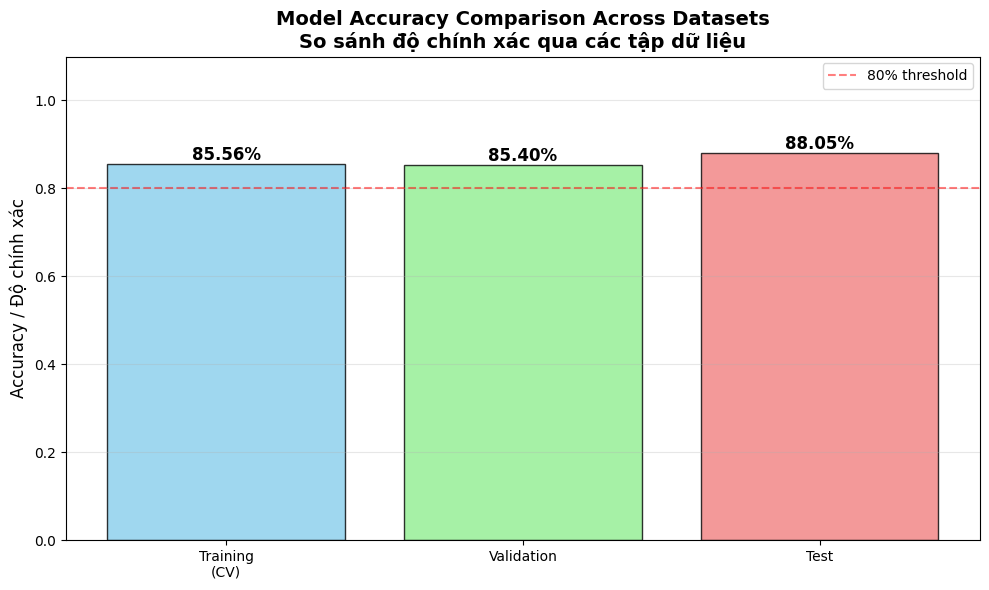


MODEL PERFORMANCE SUMMARY / TỔNG KẾT HIỆU SUẤT MÔ HÌNH
Cross-Validation Accuracy: 85.56%
Validation Accuracy:       85.40%
Test Accuracy:             88.05%

Best Parameters / Tham số tốt nhất:
  classifier__criterion: entropy
  classifier__max_depth: 10
  classifier__n_estimators: 1000
CPU times: user 2.54 s, sys: 4.15 s, total: 6.7 s
Wall time: 180 ms


In [29]:
%%time
# Vẽ biểu đồ tổng kết so sánh accuracy giữa các tập dữ liệu
datasets = ['Training\n(CV)', 'Validation', 'Test']
accuracies = [grid_search.best_score_, accuracy, test_accuracy]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(datasets, accuracies, color=['skyblue', 'lightgreen', 'lightcoral'], alpha=0.8, edgecolor='black')

# Thêm giá trị lên từng cột
for bar, acc in zip(bars, accuracies):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{acc*100:.2f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_ylabel('Accuracy / Độ chính xác', fontsize=12)
ax.set_title('Model Accuracy Comparison Across Datasets\nSo sánh độ chính xác qua các tập dữ liệu', fontsize=14, fontweight='bold')
ax.set_ylim([0, 1.1])
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0.8, color='red', linestyle='--', alpha=0.5, label='80% threshold')
ax.legend()

plt.tight_layout()
plt.show()

# In tổng kết
print("\n" + "="*60)
print("MODEL PERFORMANCE SUMMARY / TỔNG KẾT HIỆU SUẤT MÔ HÌNH")
print("="*60)
print(f"Cross-Validation Accuracy: {grid_search.best_score_*100:.2f}%")
print(f"Validation Accuracy:       {accuracy*100:.2f}%")
print(f"Test Accuracy:             {test_accuracy*100:.2f}%")
print(f"\nBest Parameters / Tham số tốt nhất:")
for param, value in grid_search.best_params_.items():
    print(f"  {param}: {value}")
print("="*60)

#### 6. Model Performance Summary / Tổng kết hiệu suất mô hình

In [30]:
%%time
# Tính độ chính xác theo từng lớp
from sklearn.metrics import precision_recall_fscore_support

precision_val, recall_val, f1_val, _ = precision_recall_fscore_support(y_val, y_pred, average=None)
precision_test, recall_test, f1_test, _ = precision_recall_fscore_support(y_test, y_pred_test, average=None)

# Tạo DataFrame để dễ visualize
metrics_df = pd.DataFrame({
    'Class': class_names,
    'Precision (Val)': precision_val,
    'Recall (Val)': recall_val,
    'F1-Score (Val)': f1_val,
    'Precision (Test)': precision_test,
    'Recall (Test)': recall_test,
    'F1-Score (Test)': f1_test
})

# Vẽ biểu đồ so sánh các metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

x = np.arange(len(class_names))
width = 0.35

# Precision
axes[0].bar(x - width/2, precision_val, width, label='Validation', alpha=0.8)
axes[0].bar(x + width/2, precision_test, width, label='Test', alpha=0.8)
axes[0].set_xlabel('Class / Lớp')
axes[0].set_ylabel('Precision / Độ chính xác')
axes[0].set_title('Precision by Class\nĐộ chính xác theo lớp')
axes[0].set_xticks(x)
axes[0].set_xticklabels(class_names, rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Recall
axes[1].bar(x - width/2, recall_val, width, label='Validation', alpha=0.8)
axes[1].bar(x + width/2, recall_test, width, label='Test', alpha=0.8)
axes[1].set_xlabel('Class / Lớp')
axes[1].set_ylabel('Recall / Độ phủ')
axes[1].set_title('Recall by Class\nĐộ phủ theo lớp')
axes[1].set_xticks(x)
axes[1].set_xticklabels(class_names, rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# F1-Score
axes[2].bar(x - width/2, f1_val, width, label='Validation', alpha=0.8)
axes[2].bar(x + width/2, f1_test, width, label='Test', alpha=0.8)
axes[2].set_xlabel('Class / Lớp')
axes[2].set_ylabel('F1-Score')
axes[2].set_title('F1-Score by Class\nF1-Score theo lớp')
axes[2].set_xticks(x)
axes[2].set_xticklabels(class_names, rotation=45, ha='right')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Hiển thị bảng metrics
print("\nDetailed Metrics Table / Bảng metrics chi tiết:")
print(metrics_df.to_string(index=False))

NameError: name 'class_names' is not defined

In [31]:
%%time
# Biểu đồ cumulative importance (tích lũy)
importance_sorted = importance_df.sort_values('Importance', ascending=False).reset_index(drop=True)
cumulative_importance = np.cumsum(importance_sorted['Importance'])

plt.figure(figsize=(12, 6))
plt.plot(range(len(cumulative_importance)), cumulative_importance, 'b-o', linewidth=2, markersize=6)

# Thêm đường ngang tại 80%, 90%, 95%
thresholds = [0.8, 0.9, 0.95]
colors_thresh = ['red', 'orange', 'green']
for thresh, color in zip(thresholds, colors_thresh):
    n_features_needed = np.argmax(cumulative_importance >= thresh) + 1
    plt.axhline(y=thresh, color=color, linestyle='--', alpha=0.7, 
                label=f'{thresh*100:.0f}% importance ({n_features_needed} features)')
    plt.axvline(x=n_features_needed-1, color=color, linestyle='--', alpha=0.3)

plt.xlabel('Number of Features / Số lượng đặc trưng', fontsize=11)
plt.ylabel('Cumulative Importance / Mức độ quan trọng tích lũy', fontsize=11)
plt.title('Cumulative Feature Importance\nMức độ quan trọng tích lũy của đặc trưng', 
          fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# In thống kê
print("\n" + "="*70)
print("CUMULATIVE IMPORTANCE ANALYSIS / PHÂN TÍCH TÍCH LŨY")
print("="*70)
for thresh in thresholds:
    n_features = np.argmax(cumulative_importance >= thresh) + 1
    print(f"Features needed for {thresh*100:.0f}% importance: {n_features}/{len(importance_df)} "
          f"({n_features/len(importance_df)*100:.1f}%)")
print("="*70)

NameError: name 'importance_df' is not defined

In [32]:
%%time
# Biểu đồ phân nhóm: NDVI vs Sentinel-1 importance
# Tính tổng importance cho từng nhóm
total_importance = importance_df['Importance'].sum()

# Tách NDVI features và Sentinel-1 features
ndvi_features = importance_df[importance_df['Feature'].str.contains('NDVI', case=False)]
sentinel1_features = importance_df[importance_df['Feature'].str.contains('VH|VV', case=False, regex=True)]

ndvi_importance = ndvi_features['Importance'].sum()
sentinel1_importance = sentinel1_features['Importance'].sum()

# Vẽ biểu đồ tròn (Pie chart)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ tròn: So sánh NDVI vs Sentinel-1
categories = ['NDVI Features\n(Sentinel-2)', 'Sentinel-1 Features\n(VH & VV)']
importances = [ndvi_importance, sentinel1_importance]
colors_pie = ['#3498db', '#e74c3c']
explode = (0.05, 0.05)

wedges, texts, autotexts = axes[0].pie(importances, labels=categories, autopct='%1.1f%%',
                                        colors=colors_pie, explode=explode, startangle=90,
                                        textprops={'fontsize': 11, 'weight': 'bold'})
axes[0].set_title('Feature Importance by Sensor Type\nMức độ quan trọng theo loại cảm biến', 
                  fontsize=12, fontweight='bold', pad=20)

# Biểu đồ cột: Tổng hợp theo nhóm
axes[1].bar(categories, importances, color=colors_pie, alpha=0.7, edgecolor='black', width=0.5)
axes[1].set_ylabel('Total Importance / Tổng mức độ quan trọng', fontsize=11)
axes[1].set_title('Total Importance by Sensor Group\nTổng mức độ quan trọng theo nhóm cảm biến', 
                  fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên cột
for i, (cat, imp) in enumerate(zip(categories, importances)):
    axes[1].text(i, imp, f'{imp:.3f}\n({imp/total_importance*100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("FEATURE GROUP SUMMARY / TỔNG KẾT THEO NHÓM ĐẶC TRƯNG")
print("="*70)
print(f"NDVI Features (Sentinel-2):      {ndvi_importance:.4f} ({ndvi_importance/total_importance*100:.1f}%)")
print(f"Sentinel-1 Features (VH & VV):   {sentinel1_importance:.4f} ({sentinel1_importance/total_importance*100:.1f}%)")
print(f"Total:                           {total_importance:.4f} (100.0%)")
print("="*70)

NameError: name 'importance_df' is not defined

NameError: name 'importance_df' is not defined

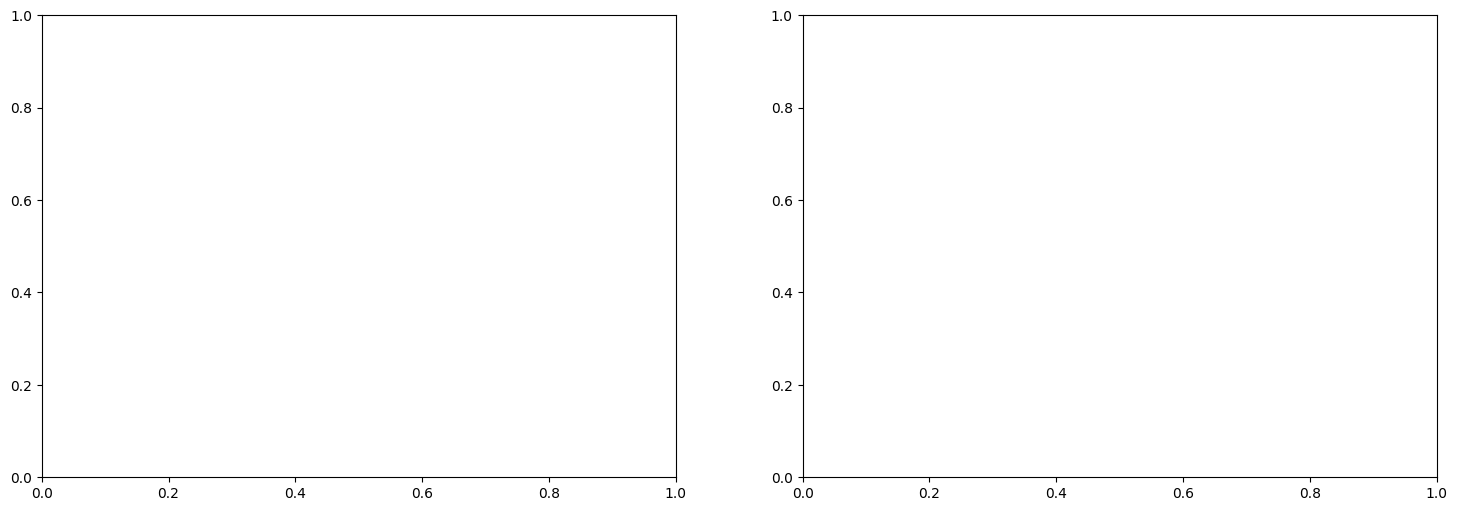

In [33]:
%%time
# Vẽ biểu đồ Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Biểu đồ 1: Tất cả features (horizontal bar chart)
colors = plt.cm.viridis(np.linspace(0, 1, len(importance_df)))
axes[0].barh(range(len(importance_df)), importance_df['Importance'], color=colors, alpha=0.8)
axes[0].set_yticks(range(len(importance_df)))
axes[0].set_yticklabels(importance_df['Feature'])
axes[0].set_xlabel('Importance Score / Điểm quan trọng')
axes[0].set_title('Feature Importance - All Features\nMức độ quan trọng - Tất cả đặc trưng')
axes[0].grid(True, alpha=0.3, axis='x')
axes[0].invert_yaxis()

# Biểu đồ 2: Top 10 features quan trọng nhất
top_n = min(10, len(importance_df))
top_importance = importance_df.head(top_n)
colors_top = plt.cm.plasma(np.linspace(0.2, 0.9, top_n))

bars = axes[1].bar(range(top_n), top_importance['Importance'], color=colors_top, alpha=0.8, edgecolor='black')
axes[1].set_xticks(range(top_n))
axes[1].set_xticklabels(top_importance['Feature'], rotation=45, ha='right')
axes[1].set_ylabel('Importance Score / Điểm quan trọng')
axes[1].set_title(f'Top {top_n} Most Important Features\n{top_n} đặc trưng quan trọng nhất')
axes[1].grid(True, alpha=0.3, axis='y')

# Thêm giá trị lên từng cột
for bar, imp in zip(bars, top_importance['Importance']):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                f'{imp:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

**Note:** The `importance_df` DataFrame is calculated in the cell above under section 7. Run that cell first before running the visualization cells below.

**Lưu ý:** DataFrame `importance_df` được tính toán ở ô phía trên trong mục 7. Chạy ô đó trước khi chạy các ô vẽ biểu đồ bên dưới.

#### 7. Feature Importance / Mức độ quan trọng của đặc trưng

In [ ]:
%%time
# Lấy mô hình Random Forest tốt nhất từ pipeline
best_rf_model = grid_search.best_estimator_.named_steps['classifier']

# Lấy feature importances
feature_importances = best_rf_model.feature_importances_

# Tạo tên cho các features
# Giả sử có 12 tháng NDVI + 1 VH + 1 VV
n_ndvi_months = 12
feature_names = [f'NDVI_Month_{i+1}' for i in range(n_ndvi_months)] + ['VH (Sentinel-1)', 'VV (Sentinel-1)']

# Nếu số features không khớp, tạo tên generic
if len(feature_importances) != len(feature_names):
    n_features = len(feature_importances)
    feature_names = [f'Feature_{i+1}' for i in range(n_features)]

# Tạo DataFrame và sắp xếp theo importance
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("Feature Importance Ranking / Xếp hạng mức độ quan trọng của đặc trưng:")
print("="*70)
for idx, row in importance_df.iterrows():
    print(f"{row['Feature']:25s}: {row['Importance']:.4f} ({row['Importance']*100:.2f}%)")
print("="*70)

#### 5. Per-Class Accuracy / Độ chính xác theo từng lớp

In [35]:
%%time
# Classification report chi tiết
print("="*60)
print("VALIDATION SET - TẬP VALIDATION")
print("="*60)
print(classification_report(y_val, y_pred, target_names=class_names))

print("\n" + "="*60)
print("TEST SET - TẬP TEST")
print("="*60)
print(classification_report(y_test, y_pred_test, target_names=class_names))

VALIDATION SET - TẬP VALIDATION


NameError: name 'class_names' is not defined

#### 4. Classification Report / Báo cáo phân loại chi tiết

NameError: name 'confusion_matrix' is not defined

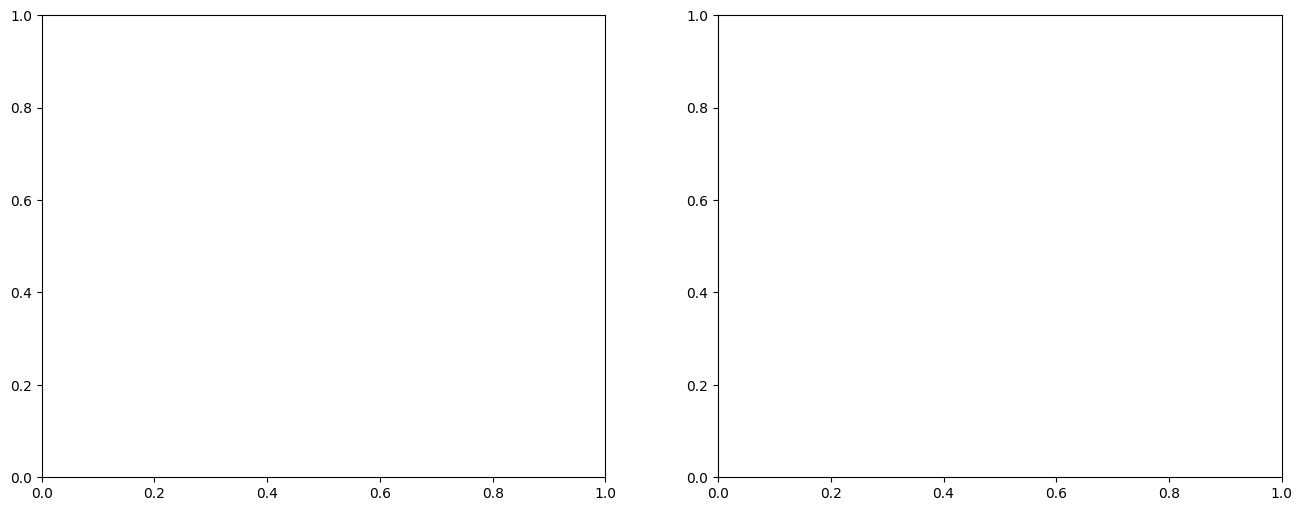

In [ ]:
%%time
# Confusion Matrix cho tập validation và test
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Validation confusion matrix
cm_val = confusion_matrix(y_val, y_pred)
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[0])
axes[0].set_title('Confusion Matrix - Validation Set\nMa trận nhầm lẫn - Tập validation')
axes[0].set_ylabel('True Label / Nhãn thực')
axes[0].set_xlabel('Predicted Label / Nhãn dự đoán')

# Test confusion matrix
cm_test = confusion_matrix(y_test, y_pred_test)
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names, ax=axes[1])
axes[1].set_title('Confusion Matrix - Test Set\nMa trận nhầm lẫn - Tập test')
axes[1].set_ylabel('True Label / Nhãn thực')
axes[1].set_xlabel('Predicted Label / Nhãn dự đoán')

plt.tight_layout()
plt.show()

#### 3. Confusion Matrix / Ma trận nhầm lẫn

In [37]:
%%time
# Vẽ learning curves để thấy hiệu suất qua các kích thước tập train khác nhau
train_sizes, train_scores, val_scores = learning_curve(
    grid_search.best_estimator_, 
    X_train, 
    y_train, 
    cv=5, 
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
val_mean = np.mean(val_scores, axis=1)
val_std = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, 'o-', color='r', label='Training score')
plt.plot(train_sizes, val_mean, 'o-', color='g', label='Cross-validation score')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.1, color='r')
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.1, color='g')

plt.xlabel('Training Set Size / Kích thước tập huấn luyện')
plt.ylabel('Accuracy Score / Độ chính xác')
plt.title('Learning Curves\nĐường cong học tập')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

NameError: name 'learning_curve' is not defined

#### 2. Learning Curves / Đường cong học tập

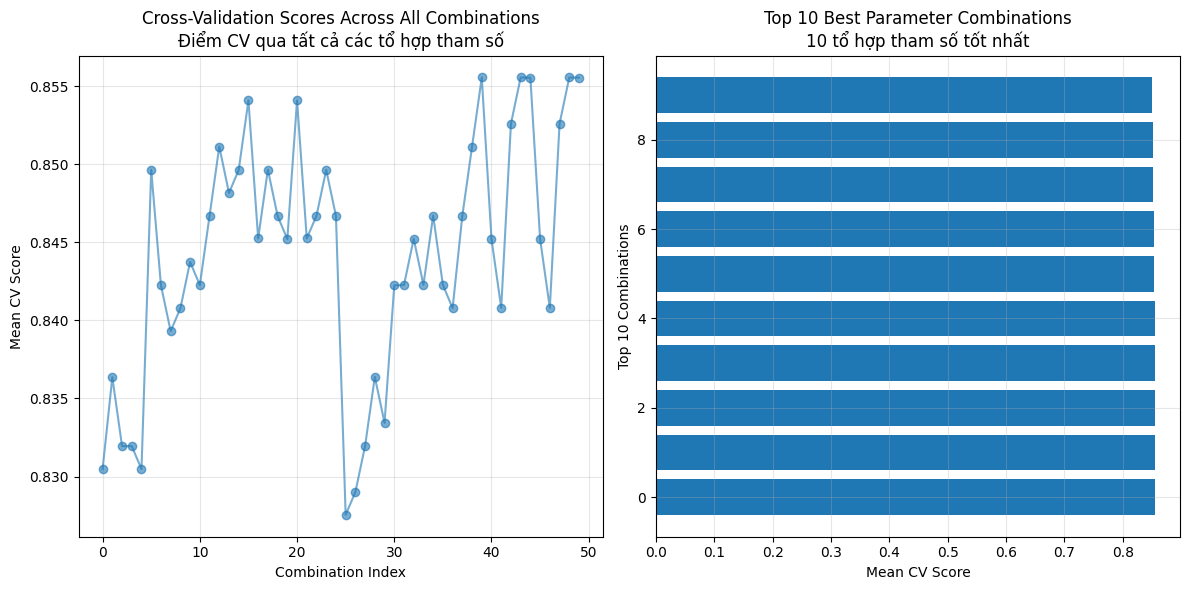

Best CV Score: 0.8556
Điểm CV tốt nhất: 0.8556
CPU times: user 339 ms, sys: 150 ms, total: 489 ms
Wall time: 236 ms


In [38]:
%%time
# Vẽ biểu đồ kết quả Cross-Validation từ GridSearchCV
cv_results = pd.DataFrame(grid_search.cv_results_)

# Lấy top 10 kết quả tốt nhất
top_results = cv_results.nlargest(10, 'mean_test_score')

plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(cv_results['mean_test_score'], marker='o', linestyle='-', alpha=0.6)
plt.xlabel('Combination Index')
plt.ylabel('Mean CV Score')
plt.title('Cross-Validation Scores Across All Combinations\nĐiểm CV qua tất cả các tổ hợp tham số')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.barh(range(len(top_results)), top_results['mean_test_score'].values)
plt.xlabel('Mean CV Score')
plt.ylabel('Top 10 Combinations')
plt.title('Top 10 Best Parameter Combinations\n10 tổ hợp tham số tốt nhất')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best CV Score: {grid_search.best_score_:.4f}")
print(f"Điểm CV tốt nhất: {grid_search.best_score_:.4f}")

#### 1. Cross-Validation Scores / Điểm số xác thực chéo

In [ ]:
# Định nghĩa tên các lớp / Define class names
class_names = ['Lua tom', 'Lua', 'CHN', 'CLN', 'TS', 'Song', 'Dat xay dung', 'Rung']
print(f"Defined {len(class_names)} classes: {', '.join(class_names)}")

### Model Performance Visualization / Trực quan hóa hiệu suất mô hình

### Save train model/ Lưu trữ mô hình huấn luyện

In [40]:
dir_save_model = "model_train"
if not os.path.exists(dir_save_model):
    os.mkdir(dir_save_model)
joblib.dump(grid_search, os.path.join(dir_save_model, "model.joblib"))

['model_train/model.joblib']

In [41]:
client.close()
cluster.close()